In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!pip install open_clip_torch timm scikit-learn matplotlib seaborn pandas -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00


In [ ]:
import os, io, json, pickle, random, shutil, itertools
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import torchvision.transforms.functional as TF
from torchvision.utils import make_grid
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from PIL import Image
import open_clip
import timm

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

RUN_518_PROBE = True
RUN_LEGACY_20 = True

Device: cuda


In [ ]:
PROJECT_DIR  = Path('/content/drive/MyDrive/Indian_Food_Research')
DATASET_PATH = PROJECT_DIR / 'datasets' / 'CompressedDataset'
FOOD101_ROOT = PROJECT_DIR / 'datasets' / 'Food101'
SPLITS_DIR   = PROJECT_DIR / 'splits'
RESULTS_DIR  = PROJECT_DIR / 'results'
FIGURES_DIR  = PROJECT_DIR / 'figures'
REPORTS_DIR  = PROJECT_DIR / 'reports'
for d in (RESULTS_DIR, FIGURES_DIR, REPORTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

In [ ]:
LOCAL_DS = DATASET_PATH

In [ ]:
indian_full        = datasets.ImageFolder(str(LOCAL_DS))
indian_class_names = indian_full.classes
NUM_CLASSES        = len(indian_class_names)

print(f'Indian benchmark: {len(indian_full.samples)} images | {NUM_CLASSES} classes')
assert NUM_CLASSES == 100, f'Expected 100 classes, got {NUM_CLASSES} — Drive may be mid-sync. STOP.'
assert len(indian_full.samples) == 4578, f'Expected 4578 images, got {len(indian_full.samples)}. STOP.'

train_idx = pickle.load(open(SPLITS_DIR / 'train_idx.pkl', 'rb'))
val_idx   = pickle.load(open(SPLITS_DIR / 'val_idx.pkl',   'rb'))
test_idx  = pickle.load(open(SPLITS_DIR / 'test_idx.pkl',  'rb'))

assert not (set(train_idx) & set(test_idx)), 'train/test overlap'
assert not (set(val_idx)   & set(test_idx)), 'val/test overlap'
assert max(max(train_idx), max(val_idx), max(test_idx)) < len(indian_full.samples)
print(f'Splits: train {len(train_idx)} | val {len(val_idx)} | test {len(test_idx)}  — guards passed')

class_csv = REPORTS_DIR / 'class_names.csv'
if class_csv.exists():
    csv_names = pd.read_csv(class_csv)['Class'].tolist()
    assert csv_names == indian_class_names, 'class_names.csv disagrees with ImageFolder ordering. STOP.'
    print('class_names.csv ordering verified against ImageFolder.')
class_names = indian_class_names

Indian benchmark: 4578 images | 100 classes
Splits: train 3127 | val 678 | test 678  — guards passed
class_names.csv ordering verified against ImageFolder.


In [ ]:
le_csv = RESULTS_DIR / 'label_efficiency_results.csv'
if le_csv.exists():
    le = pd.read_csv(le_csv)
    row = le[(le['method'] == 'resnet50_scratch') & (le['fraction'] == 1.0)]
    RESNET_SCRATCH_ACC = float(row['test_acc'].iloc[0])
    print(f'ResNet-50 (scratch), from label_efficiency_results.csv: {RESNET_SCRATCH_ACC*100:.2f}%')
else:
    RESNET_SCRATCH_ACC = None
    print('label_efficiency_results.csv not found ')

label_efficiency_results.csv not found 


In [ ]:
candidates = [FOOD101_ROOT / 'food-101' / 'images', FOOD101_ROOT / 'images', FOOD101_ROOT]
FOOD101_IMAGES = None
for c in candidates:
    if c.is_dir():
        n_sub = len([p for p in c.iterdir() if p.is_dir()])
        print(f'{c}  ->  {n_sub} sub-directories')
        if n_sub > 50:
            FOOD101_IMAGES = c
            break

assert FOOD101_IMAGES is not None, (
    'Food-101 image root not found. Expected <root>/food-101/images with 101 class folders. '
    'Re-download: torchvision.datasets.Food101(root=FOOD101_ROOT, split="test", download=True)')

META_DIR = FOOD101_IMAGES.parent / 'meta'
western_all = datasets.ImageFolder(str(FOOD101_IMAGES))
print(f'\nFood-101: {len(western_all.classes)} classes | {len(western_all.samples)} images')
assert len(western_all.classes) == 101, (
    f'GUARD FAILED: {len(western_all.classes)} classes, expected 101.')
print('Guard passed — the directory-structure defect is not present.')

/content/drive/MyDrive/Indian_Food_Research/datasets/Food101/food-101/images  ->  101 sub-directories

Food-101: 101 classes | 101000 images
Guard passed — the directory-structure defect is not present.


In [ ]:
test_json = META_DIR / 'test.json'
if test_json.exists():
    meta = json.loads(test_json.read_text())
    official_test = {cls: [FOOD101_IMAGES / f'{rel}.jpg' for rel in rels] for cls, rels in meta.items()}
    print(f'Official test split: {sum(len(v) for v in official_test.values())} images '
          f'across {len(official_test)} classes')
else:
    print('meta/test.json missing — falling back to a seeded 25% per-class holdout.')
    official_test, rng = {}, random.Random(SEED)
    for cls in western_all.classes:
        files = sorted((FOOD101_IMAGES / cls).glob('*.jpg'))
        rng.shuffle(files)
        official_test[cls] = files[: max(1, len(files) // 4)]

western_pool = sorted(official_test.keys())

Official test split: 25250 images across 101 classes


In [ ]:
indian_test_counts = Counter(indian_full.targets[i] for i in test_idx)
count_profile = sorted((indian_test_counts[c] for c in range(NUM_CLASSES)), reverse=True)
print(f'Indian test: {sum(count_profile)} images | per-class min {min(count_profile)} '
      f'max {max(count_profile)} median {int(np.median(count_profile))}')

rng = random.Random(SEED)
chosen = sorted(rng.sample(western_pool, 100))

western_items = []
for cls, n_wanted in zip(chosen, count_profile):
    files = sorted(official_test[cls])
    rng.shuffle(files)
    western_items += [(p, chosen.index(cls)) for p in files[: min(n_wanted, len(files))]]

print(f'Matched Western test: {len(western_items)} images | {len(chosen)} classes')
assert len(western_items) == len(test_idx), 'Matched set size differs from the Indian test set.'
assert len(set(l for _, l in western_items)) == 100, 'A Western class ended up empty.'
print('Both sides: 100-way, 678 images, identical per-class count profile.')

Indian test: 678 images | per-class min 1 max 12 median 8
Matched Western test: 678 images | 100 classes
Both sides: 100-way, 678 images, identical per-class count profile.


In [ ]:
class PathListDataset(Dataset):
    """Western set: explicit (path, label) pairs — no index arithmetic against a foreign dataset."""
    def __init__(self, items, transform):
        self.items, self.transform = items, transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        path, label = self.items[i]
        return self.transform(Image.open(path).convert('RGB')), label


class IndexedDataset(Dataset):
    """Indian set: indices into the ImageFolder they were generated from."""
    def __init__(self, base, indices, transform):
        self.base, self.indices, self.transform = base, indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        path, label = self.base.samples[self.indices[i]]
        return self.transform(Image.open(path).convert('RGB')), label

In [ ]:
indian_templates = [
    'a photo of {}, an Indian dish',
    'a close-up photo of {} served on a plate',
    'a restaurant photo of Indian food: {}',
]
western_templates = [
    'a photo of {}, a food dish',
    'a restaurant photo of {}',
    'a close-up photo of {}',
]


def encode_prompts(names, templates, model, tokenizer):
    feats = []
    for tmpl in templates:
        tokens = tokenizer([tmpl.format(c.replace('_', ' ')) for c in names]).to(device)
        with torch.no_grad():
            tf = model.encode_text(tokens)
            tf = tf / tf.norm(dim=-1, keepdim=True)
        feats.append(tf)
    out = torch.stack(feats).mean(0)
    return out / out.norm(dim=-1, keepdim=True)


@torch.no_grad()
def run_zero_shot(loader, text_features, model):
    preds, labels = [], []
    model.eval()
    for imgs, lbs in loader:
        f = model.encode_image(imgs.to(device))
        f = f / f.norm(dim=-1, keepdim=True)
        preds.extend((f @ text_features.T).argmax(1).cpu().numpy())
        labels.extend(lbs.numpy())
    return np.array(labels), np.array(preds)


@torch.no_grad()
def extract_features(loader, model):
    F, Y = [], []
    model.eval()
    for imgs, lbs in loader:
        F.append(model(imgs.to(device)).cpu().numpy())
        Y.append(lbs.numpy())
    return np.concatenate(F), np.concatenate(Y)


def wilson(k, n, z=1.96):
    ph = k / n
    d = 1 + z ** 2 / n
    c = ph + z ** 2 / (2 * n)
    half = z * np.sqrt(ph * (1 - ph) / n + z ** 2 / (4 * n ** 2))
    return 100 * (c - half) / d, 100 * (c + half) / d


def gap_ci(corr_west, corr_ind, n_boot=10000, alpha=0.05):
    cw, ci_ = np.asarray(corr_west, float), np.asarray(corr_ind, float)
    rs = np.random.RandomState(SEED)
    gaps = np.empty(n_boot)
    for b in range(n_boot):
        gaps[b] = (cw[rs.randint(0, len(cw), len(cw))].mean()
                   - ci_[rs.randint(0, len(ci_), len(ci_))].mean())
    return (100 * np.percentile(gaps, 100 * alpha / 2),
            100 * np.percentile(gaps, 100 * (1 - alpha / 2)))


def save_fig(name):
    for ext in ('png', 'pdf'):
        plt.savefig(FIGURES_DIR / f'{name}.{ext}', dpi=300, bbox_inches='tight')
    print('Saved ->', FIGURES_DIR / f'{name}.png')

In [ ]:
MODELS = [
    ('CLIP ViT-B/32', 'ViT-B-32',             'laion2b_s34b_b79k', 64),
    ('CLIP ViT-L/14', 'ViT-L-14',             'laion2b_s32b_b82k', 32),
    ('SigLIP SO400M', 'ViT-SO400M-14-SigLIP', 'webli',             32),
]

CKPT = RESULTS_DIR / 'zeroshot_fixed_checkpoints.json'
records = json.loads(CKPT.read_text()) if CKPT.exists() else []
done = {r['model'] for r in records}
print('Already done:', done or '(none)')

zs_preds = {}
for disp, arch, pretrained, bs in MODELS:
    if disp in done:
        print('SKIP', disp)
        continue
    print(f'\n=== {disp} ===')
    model, _, preprocess = open_clip.create_model_and_transforms(arch, pretrained=pretrained)
    tokenizer = open_clip.get_tokenizer(arch)
    model = model.to(device).eval()

    ind_loader = DataLoader(IndexedDataset(indian_full, test_idx, preprocess),
                            batch_size=bs, shuffle=False, num_workers=2)
    wes_loader = DataLoader(PathListDataset(western_items, preprocess),
                            batch_size=bs, shuffle=False, num_workers=2)

    y_ind, p_ind = run_zero_shot(ind_loader, encode_prompts(indian_class_names, indian_templates,
                                                            model, tokenizer), model)
    y_wes, p_wes = run_zero_shot(wes_loader, encode_prompts(chosen, western_templates,
                                                            model, tokenizer), model)

    c_ind, c_wes = (y_ind == p_ind).astype(int), (y_wes == p_wes).astype(int)
    acc_i, acc_w = 100 * c_ind.mean(), 100 * c_wes.mean()
    lo_i, hi_i = wilson(int(c_ind.sum()), len(c_ind))
    lo_w, hi_w = wilson(int(c_wes.sum()), len(c_wes))
    lo_g, hi_g = gap_ci(c_wes, c_ind)

    print(f'  Indian  : {acc_i:6.2f}%  [{lo_i:.2f}, {hi_i:.2f}]')
    print(f'  Western : {acc_w:6.2f}%  [{lo_w:.2f}, {hi_w:.2f}]')
    print(f'  Gap     : {acc_w - acc_i:+6.2f} pp [{lo_g:.2f}, {hi_g:.2f}]')

    records.append({'model': disp,
                    'indian_acc': acc_i, 'indian_ci': [lo_i, hi_i],
                    'western_acc': acc_w, 'western_ci': [lo_w, hi_w],
                    'gap_pp': acc_w - acc_i, 'gap_ci': [lo_g, hi_g],
                    'n': int(len(c_ind)), 'n_classes': 100})
    CKPT.write_text(json.dumps(records, indent=2))

    tag = disp.replace('/', '').replace(' ', '_')
    np.save(RESULTS_DIR / f'preds_indian_{tag}.npy', np.vstack([y_ind, p_ind]))
    np.save(RESULTS_DIR / f'preds_western_{tag}.npy', np.vstack([y_wes, p_wes]))
    zs_preds[disp] = (y_ind, p_ind)

    del model
    torch.cuda.empty_cache()

print('\nAll zero-shot runs complete.')

Already done: {'SigLIP SO400M', 'CLIP ViT-B/32', 'CLIP ViT-L/14'}
SKIP CLIP ViT-B/32
SKIP CLIP ViT-L/14
SKIP SigLIP SO400M

All zero-shot runs complete.


In [ ]:
table5 = pd.DataFrame([{
    'Model': r['model'],
    'Indian Top-1 (%)':  f"{r['indian_acc']:.2f} [{r['indian_ci'][0]:.1f}, {r['indian_ci'][1]:.1f}]",
    'Western Top-1 (%)': f"{r['western_acc']:.2f} [{r['western_ci'][0]:.1f}, {r['western_ci'][1]:.1f}]",
    'Gap (pp)':          f"{r['gap_pp']:.2f} [{r['gap_ci'][0]:.1f}, {r['gap_ci'][1]:.1f}]",
} for r in records])

table5.to_csv(RESULTS_DIR / 'table5_cultural_gap_FIXED.csv', index=False)
print(table5.to_string(index=False))
print('\nProtocol: both sides 100-way, 678 images, matched per-class counts, Food-101 official '
      'test split, 3 averaged prompt templates, 95% Wilson CIs.')

        Model   Indian Top-1 (%)  Western Top-1 (%)           Gap (pp)
CLIP ViT-B/32 39.38 [35.8, 43.1] 82.30 [79.2, 85.0] 42.92 [38.2, 47.5]
CLIP ViT-L/14 44.84 [41.1, 48.6] 90.41 [88.0, 92.4] 45.58 [41.3, 49.9]
SigLIP SO400M 74.63 [71.2, 77.8] 95.87 [94.1, 97.1] 21.24 [17.7, 24.9]

Protocol: both sides 100-way, 678 images, matched per-class counts, Food-101 official test split, 3 averaged prompt templates, 95% Wilson CIs.


Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig6_cultural_gap_FIXED.png


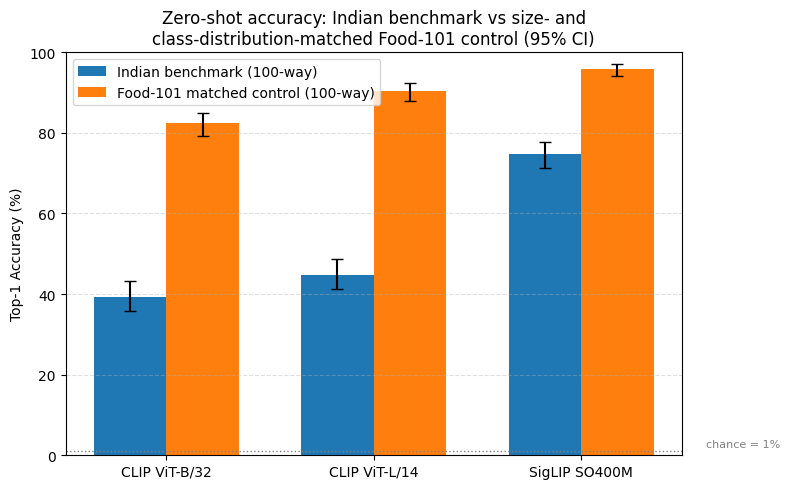

In [ ]:
labels = [r['model'] for r in records]
ind = [r['indian_acc'] for r in records]
wes = [r['western_acc'] for r in records]
ind_err = np.array([[r['indian_acc'] - r['indian_ci'][0] for r in records],
                    [r['indian_ci'][1] - r['indian_acc'] for r in records]])
wes_err = np.array([[r['western_acc'] - r['western_ci'][0] for r in records],
                    [r['western_ci'][1] - r['western_acc'] for r in records]])

x, w = np.arange(len(labels)), 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w / 2, ind, w, yerr=ind_err, capsize=4, label='Indian benchmark (100-way)')
plt.bar(x + w / 2, wes, w, yerr=wes_err, capsize=4, label='Food-101 matched control (100-way)')
plt.axhline(1.0, ls=':', lw=1, color='grey')
plt.text(len(labels) - 0.4, 2.0, 'chance = 1%', fontsize=8, color='grey')
plt.xticks(x, labels)
plt.ylabel('Top-1 Accuracy (%)')
plt.ylim(0, 100)
plt.title('Zero-shot accuracy: Indian benchmark vs size- and\nclass-distribution-matched Food-101 control (95% CI)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig('fig6_cultural_gap_FIXED')
plt.show()

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig6b_cultural_gap_bars_FIXED.png


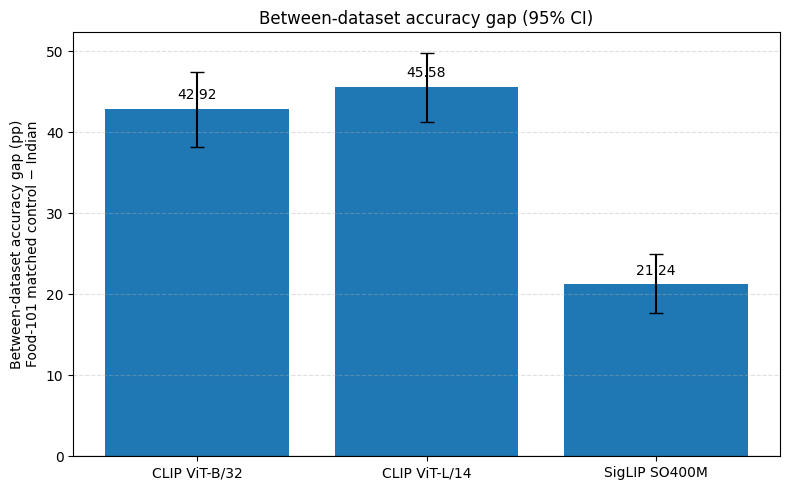

In [ ]:
plt.figure(figsize=(8, 5))
gaps = [r['gap_pp'] for r in records]
err = np.array([[r['gap_pp'] - r['gap_ci'][0] for r in records],
                [r['gap_ci'][1] - r['gap_pp'] for r in records]])
bars = plt.bar(labels, gaps, yerr=err, capsize=5)
for b, g in zip(bars, gaps):
    plt.text(b.get_x() + b.get_width() / 2, g + 1.2, f'{g:.2f}', ha='center', fontsize=10)
plt.axhline(0, color='black', lw=0.8)
plt.ylabel('Between-dataset accuracy gap (pp)\nFood-101 matched control − Indian')
plt.title('Between-dataset accuracy gap (95% CI)')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
save_fig('fig6b_cultural_gap_bars_FIXED')
plt.show()

In [ ]:
if RUN_LEGACY_20:
    legacy_20 = ['apple_pie', 'beef_carpaccio', 'beef_tartare', 'caesar_salad', 'cheesecake',
                 'club_sandwich', 'french_fries', 'fried_calamari', 'grilled_salmon', 'hamburger',
                 'hot_dog', 'ice_cream', 'lasagna', 'macaroni_and_cheese', 'omelette', 'pizza',
                 'ravioli', 'spaghetti_bolognese', 'steak', 'waffles']
    missing = [c for c in legacy_20 if c not in official_test]
    assert not missing, f'Not in Food-101 test meta: {missing}'

    rng20 = random.Random(SEED)
    legacy_items = []
    for i, cls in enumerate(legacy_20):
        files = sorted(official_test[cls])
        rng20.shuffle(files)
        legacy_items += [(p, i) for p in files[:113]]
    print(f'Legacy set: {len(legacy_items)} images | {len(legacy_20)} classes')

    m, _, prep = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
    tok = open_clip.get_tokenizer('ViT-B-32')
    m = m.to(device).eval()
    y, p = run_zero_shot(DataLoader(PathListDataset(legacy_items, prep), batch_size=64, num_workers=2),
                         encode_prompts(legacy_20, western_templates, m, tok), m)
    acc = 100 * (y == p).mean()
    lo, hi = wilson(int((y == p).sum()), len(y))
    print(f'\nCLIP ViT-B/32, legacy 20-class Western set: {acc:.2f}% [{lo:.2f}, {hi:.2f}]')
    del m
    torch.cuda.empty_cache()
else:
    print('Skipped (RUN_LEGACY_20 = False)')

Legacy set: 2260 images | 20 classes


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

In [ ]:
dino = timm.create_model('vit_base_patch14_dinov2', pretrained=True, num_classes=0).to(device).eval()
native_cfg = timm.data.resolve_data_config({}, model=dino)
print(native_cfg)
print('DINOv2 feature dimension:', dino.num_features)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

{'input_size': (3, 518, 518), 'interpolation': 'bicubic', 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 1.0, 'crop_mode': 'center'}
DINOv2 feature dimension: 768


In [ ]:
dino518 = dino
print('DINOv2 native input size from pretrained_cfg:', native_cfg['input_size'])

FEAT_CACHE = RESULTS_DIR / 'dinov2_224_features.npz'
probe_rows = {}

tf224 = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

@torch.no_grad()
def fast_features(indices, model):
    loader = DataLoader(IndexedDataset(indian_full, indices, tf224), batch_size=128,
                        num_workers=4, shuffle=False, pin_memory=True)
    F_, Y_ = [], []
    for imgs, lbs in loader:
        with torch.autocast('cuda', dtype=torch.float16):
            f = model(imgs.to(device, non_blocking=True))
        F_.append(f.float().cpu()); Y_.append(lbs)
    return torch.cat(F_), torch.cat(Y_)

if FEAT_CACHE.exists():
    z = np.load(FEAT_CACHE)
    Xtr, ytr, Xte, yte = (torch.from_numpy(z[k]) for k in ('Xtr', 'ytr', 'Xte', 'yte'))
    print('loaded cached features')
else:
    dino224 = timm.create_model('vit_base_patch14_dinov2', pretrained=True,
                                num_classes=0, img_size=224).to(device).eval()
    Xtr, ytr = fast_features(train_idx, dino224)
    Xte, yte = fast_features(test_idx, dino224)
    np.savez(FEAT_CACHE, Xtr=Xtr.numpy(), ytr=ytr.numpy(), Xte=Xte.numpy(), yte=yte.numpy())
    del dino224
    torch.cuda.empty_cache()
print('features:', tuple(Xtr.shape), tuple(Xte.shape))

Xg, yg = Xtr.to(device), ytr.to(device)
n_cls = int(max(ytr.max(), yte.max())) + 1
torch.manual_seed(SEED)
W = torch.zeros(Xg.shape[1], n_cls, device=device, requires_grad=True)
b = torch.zeros(n_cls, device=device, requires_grad=True)
lam = 1.0 / (2 * 1.0 * len(Xg))
opt = torch.optim.LBFGS([W, b], lr=1, max_iter=500, history_size=20, line_search_fn='strong_wolfe')

def closure():
    opt.zero_grad()
    loss = torch.nn.functional.cross_entropy(Xg @ W + b, yg) + lam * (W ** 2).sum()
    loss.backward()
    return loss
opt.step(closure)

with torch.no_grad():
    p224 = (Xte.to(device) @ W + b).argmax(1).cpu().numpy()
yte = yte.numpy()
k = int((p224 == yte).sum()); lo, hi = wilson(k, len(yte))
probe_rows['logreg @ 224'] = (100 * k / len(yte), lo, hi)
print(f'\nLogistic-regression probe @ 224: {100*k/len(yte):.2f}%  [{lo:.2f}, {hi:.2f}]')
np.save(RESULTS_DIR / 'preds_probe_logreg_224.npy', np.vstack([yte, p224]))

DINOv2 native input size from pretrained_cfg: (3, 518, 518)


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


features: (3127, 768) (678, 768)

Logistic-regression probe @ 224: 94.84%  [92.91, 96.27]


In [ ]:
if RUN_518_PROBE:
    tf518 = timm.data.create_transform(**native_cfg)
    Xtr5, ytr5 = extract_features(DataLoader(IndexedDataset(indian_full, train_idx, tf518),
                                             batch_size=16, num_workers=2), dino)
    Xte5, yte5 = extract_features(DataLoader(IndexedDataset(indian_full, test_idx, tf518),
                                             batch_size=16, num_workers=2), dino)
    clf518 = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED).fit(Xtr5, ytr5)
    p518 = clf518.predict(Xte5)
    k = int((p518 == yte5).sum()); lo, hi = wilson(k, len(yte5))
    probe_rows['logreg @ 518 (native)'] = (100 * k / len(yte5), lo, hi)
    print(f'Logistic-regression probe @ 518: {100*k/len(yte5):.2f}%  [{lo:.2f}, {hi:.2f}]')
    np.save(RESULTS_DIR / 'preds_probe_logreg_518.npy', np.vstack([yte5, p518]))
else:
    print('Skipped (RUN_518_PROBE = False)')

del dino
torch.cuda.empty_cache()

Logistic-regression probe @ 518: 96.46%  [94.79, 97.61]


In [ ]:
probe_df = pd.DataFrame([{'Probe': k, 'Top-1 (%)': round(v[0], 2),
                          '95% CI': f'[{v[1]:.2f}, {v[2]:.2f}]'} for k, v in probe_rows.items()])
probe_df.to_csv(RESULTS_DIR / 'linear_probe_resolution_comparison.csv', index=False)
print(probe_df.to_string(index=False))

                Probe  Top-1 (%)         95% CI
         logreg @ 224      94.84 [92.91, 96.27]
logreg @ 518 (native)      96.46 [94.79, 97.61]


CLIP ViT-B/32 Indian accuracy: 39.38%
Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9_confusion_matrix_clip_b32.png


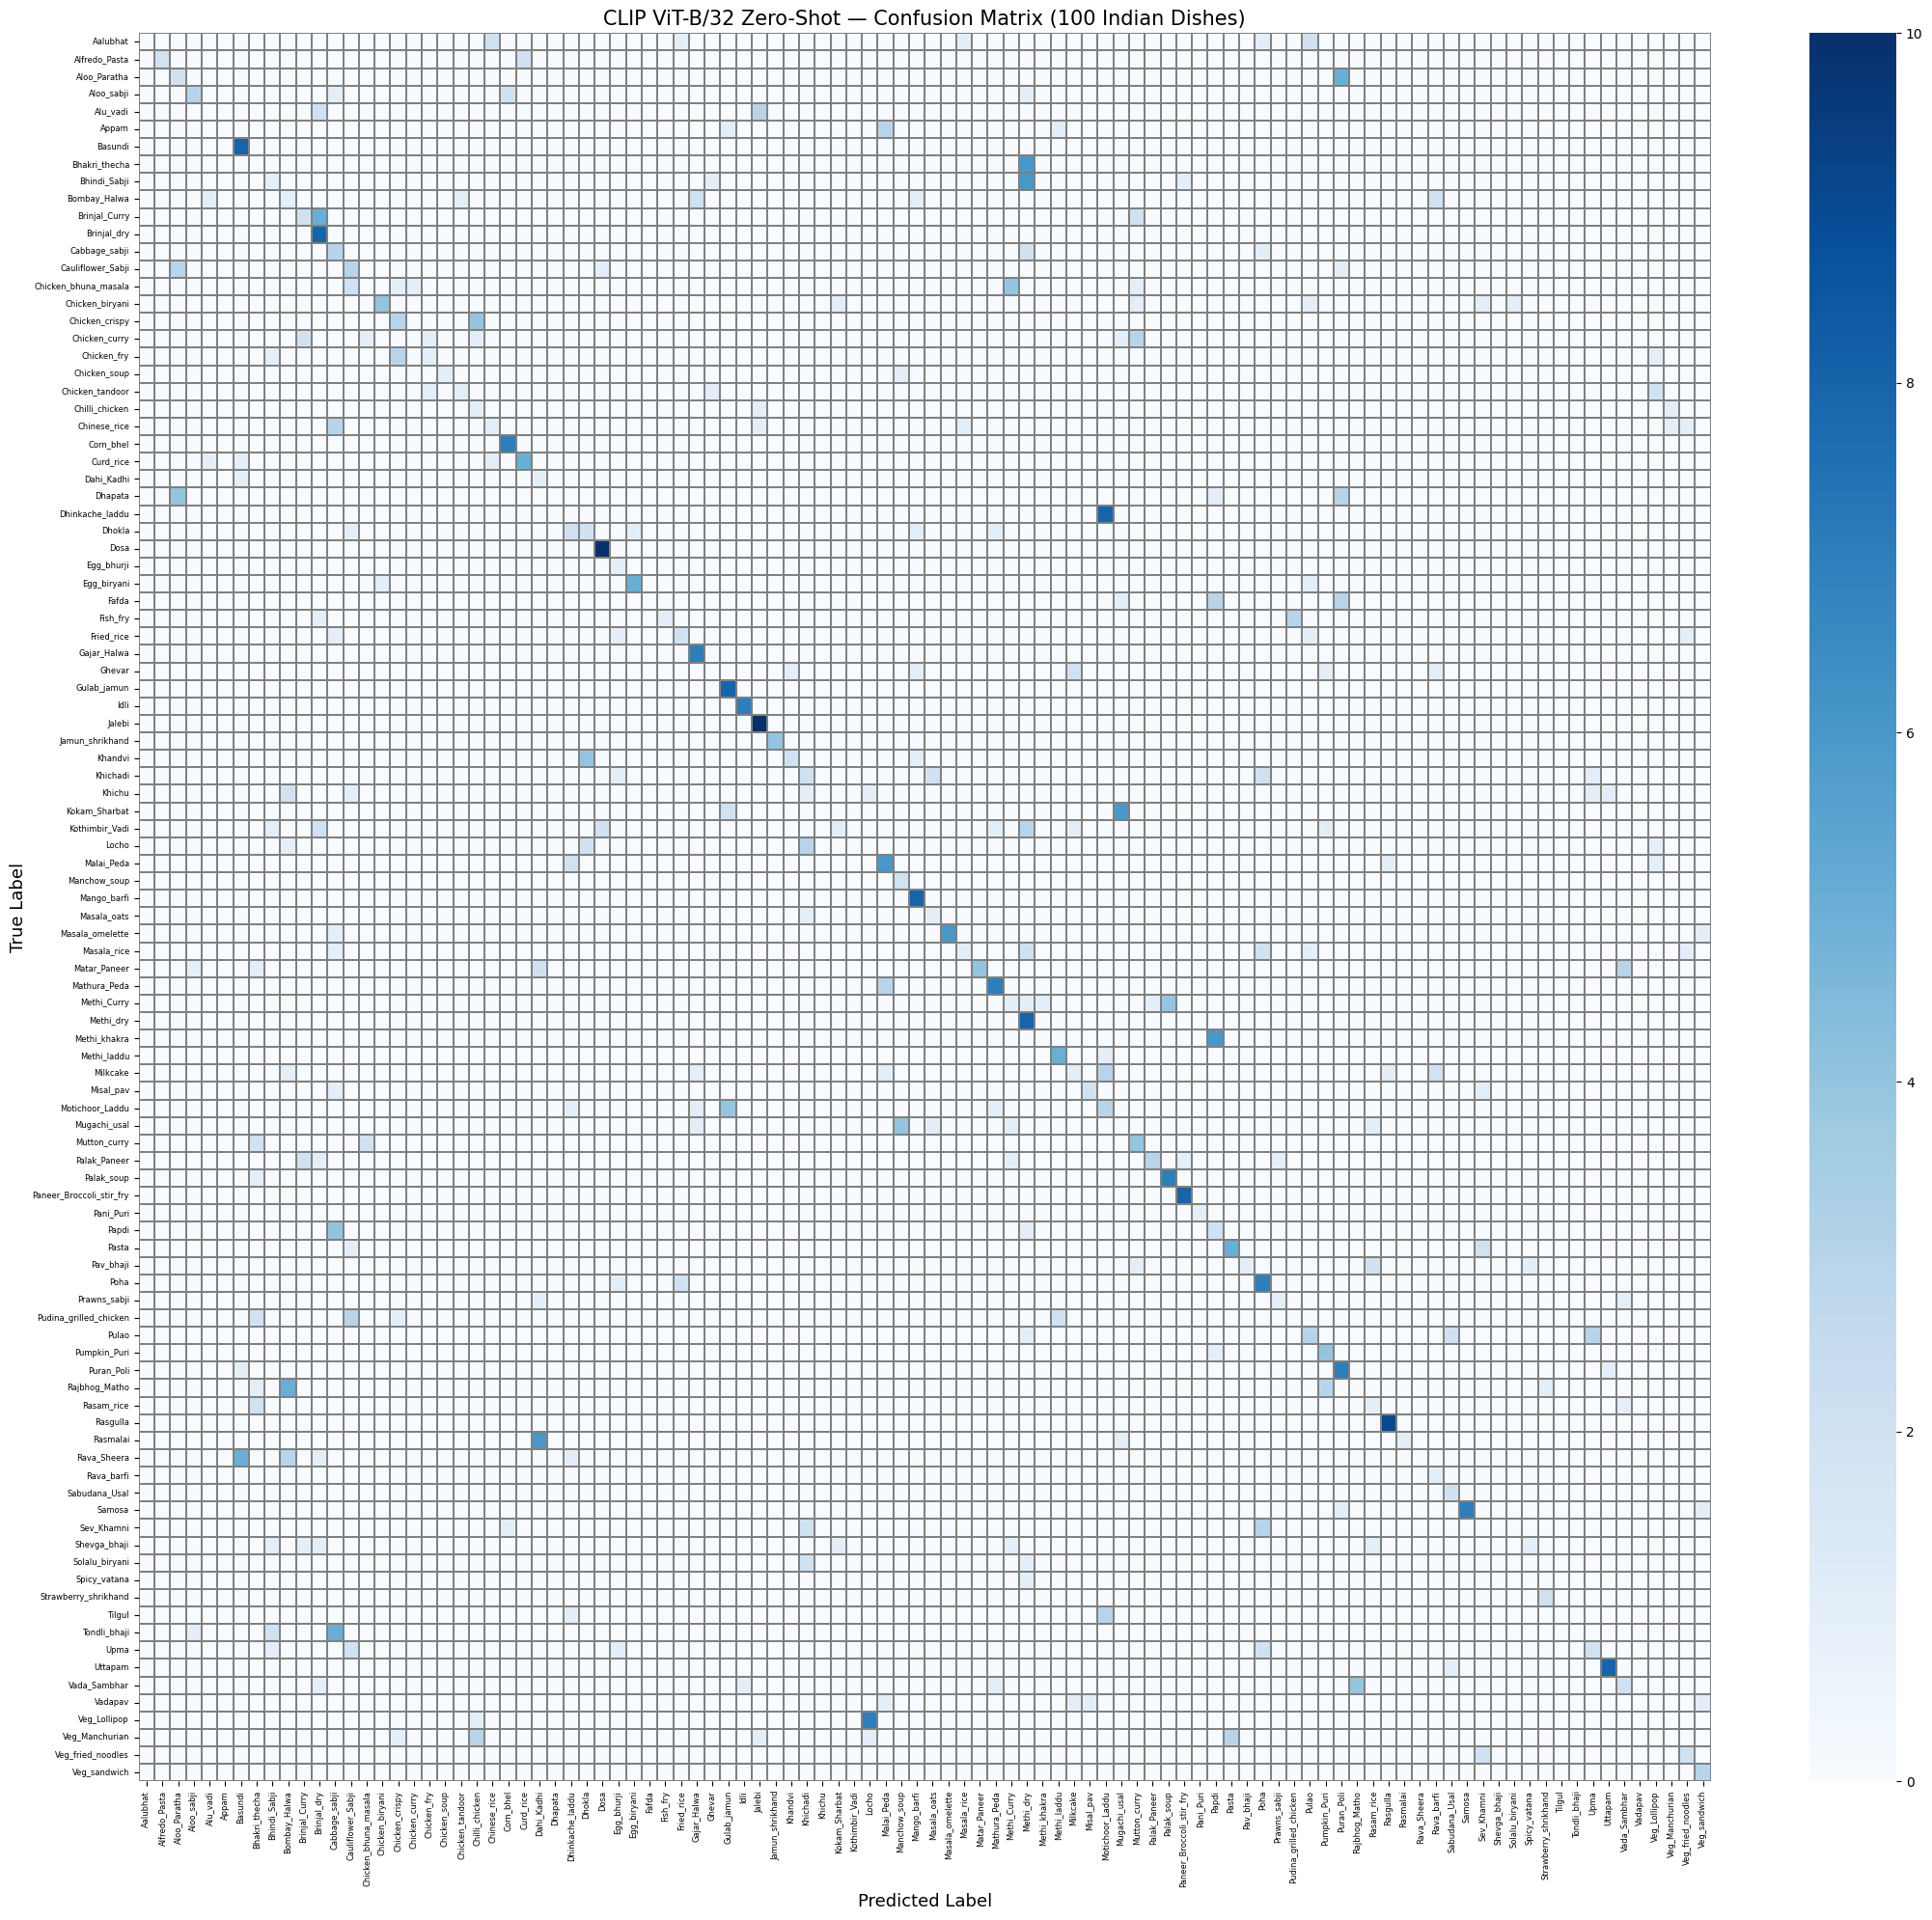

In [ ]:
tag = 'CLIP_ViT-B32'
arr = np.load(RESULTS_DIR / f'preds_indian_{tag}.npy')
labels_b32, preds_b32 = arr[0], arr[1]
print(f'CLIP ViT-B/32 Indian accuracy: {100*(labels_b32 == preds_b32).mean():.2f}%')

cm = confusion_matrix(labels_b32, preds_b32)
fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(cm, annot=False, xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', ax=ax, linewidths=0.3, linecolor='gray')
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('CLIP ViT-B/32 Zero-Shot — Confusion Matrix (100 Indian Dishes)', fontsize=15)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
save_fig('fig9_confusion_matrix_clip_b32')
plt.show()

In [ ]:
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat = np.argsort(cm_off.ravel())[::-1][:20]
rows_i, cols_i = np.unravel_index(flat, cm_off.shape)

confused_pairs = pd.DataFrame({
    'True Class':      [class_names[r] for r in rows_i],
    'Predicted Class': [class_names[c] for c in cols_i],
    'Count':           [int(cm_off[r, c]) for r, c in zip(rows_i, cols_i)],
}).head(10).reset_index(drop=True)

confused_pairs.to_csv(RESULTS_DIR / 'table8_confusion_pairs_FIXED.csv', index=False)
print(confused_pairs.to_string(index=False))
print('\nSanity note: class_names came from the same sorted ImageFolder ordering used at inference '
      '(asserted in cell 1), so these are genuine CLIP errors, not label misalignment.')

     True Class Predicted Class  Count
Dhinkache_laddu Motichoor_Laddu      8
   Veg_Lollipop           Locho      7
   Methi_khakra           Papdi      6
       Rasmalai      Dahi_Kadhi      6
  Bhakri_thecha       Methi_dry      6
  Kokam_Sharbat    Mugachi_usal      6
   Bhindi_Sabji       Methi_dry      6
  Rajbhog_Matho    Bombay_Halwa      5
   Tondli_bhaji   Cabbage_sabji      5
    Rava_Sheera         Basundi      5

Sanity note: class_names came from the same sorted ImageFolder ordering used at inference (asserted in cell 1), so these are genuine CLIP errors, not label misalignment.


Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Dhinkache_laddu_as_Motichoor_Laddu.png


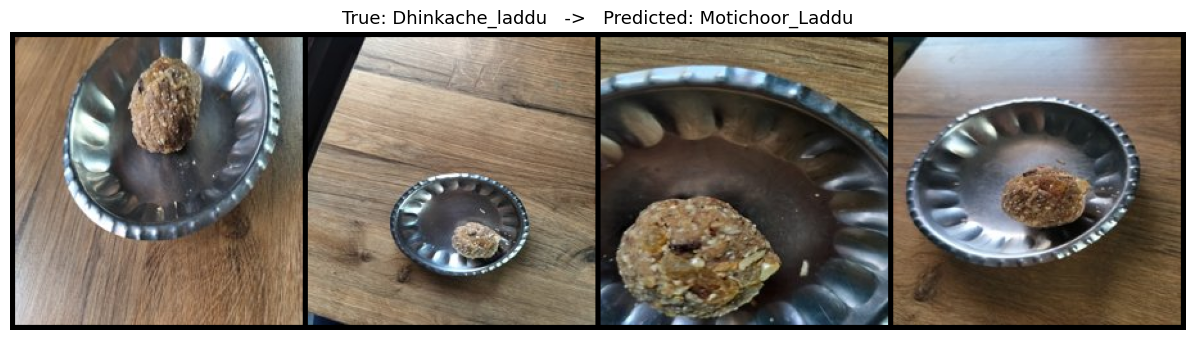

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Veg_Lollipop_as_Locho.png


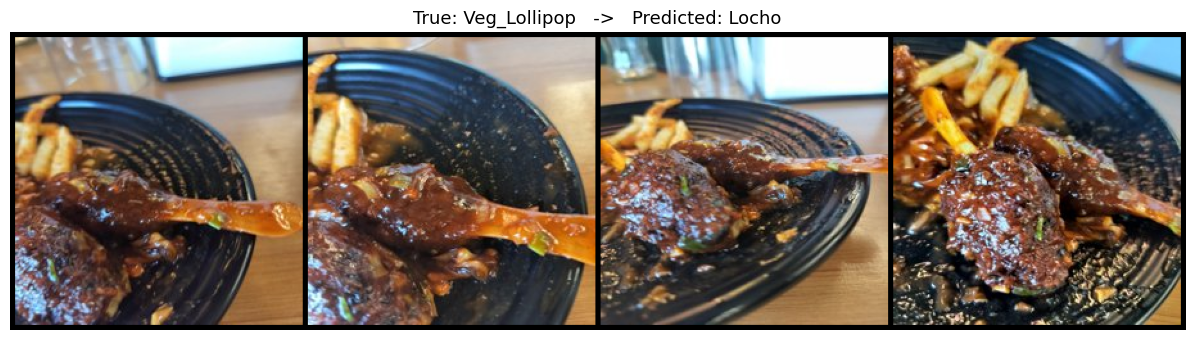

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Methi_khakra_as_Papdi.png


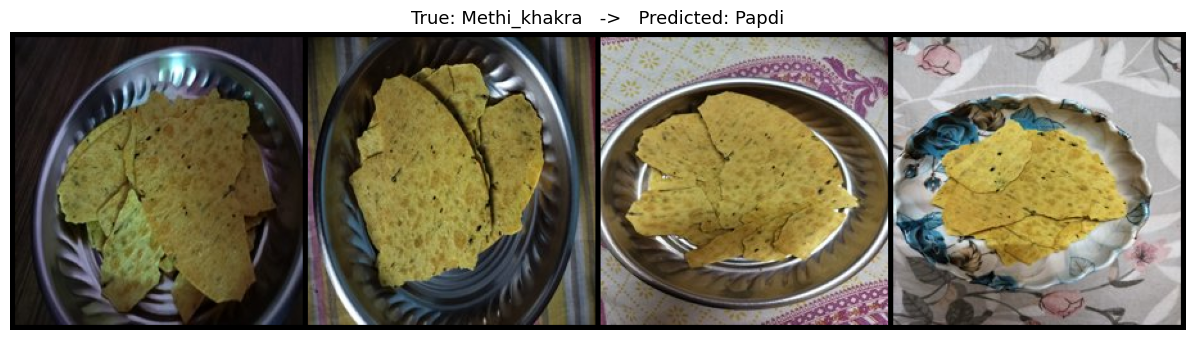

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Rasmalai_as_Dahi_Kadhi.png


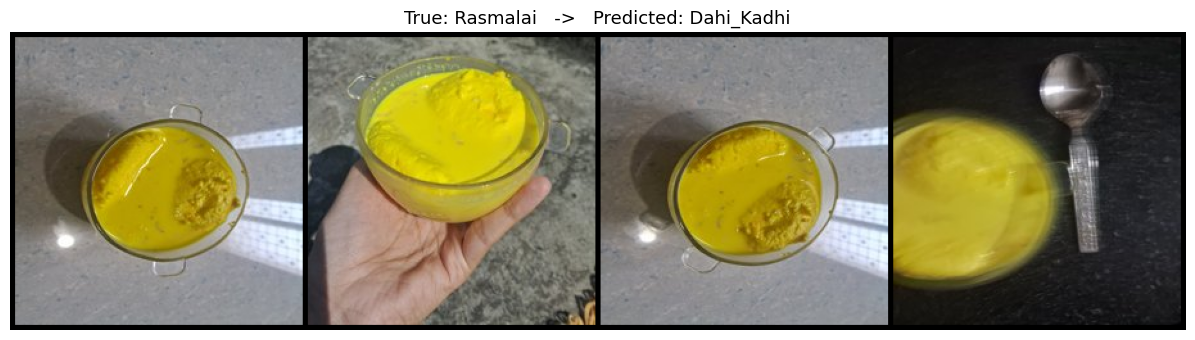

Saved -> /content/drive/MyDrive/Indian_Food_Research/figures/fig9b_failure_Bhakri_thecha_as_Methi_dry.png


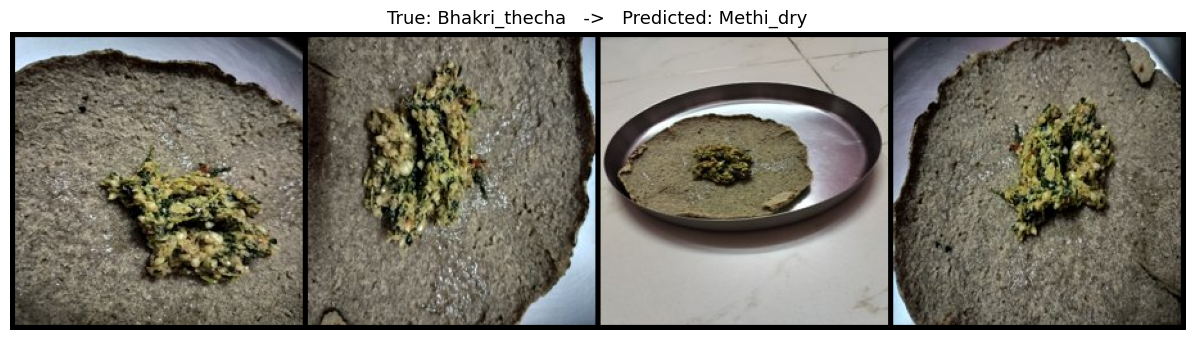

In [ ]:
display_tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])
display_test = IndexedDataset(indian_full, test_idx, display_tf)


def show_failures(true_class, pred_class, n=4):
    ti, pi = class_names.index(true_class), class_names.index(pred_class)
    hits = [i for i, (l, p) in enumerate(zip(labels_b32, preds_b32)) if l == ti and p == pi][:n]
    if not hits:
        print(f'  No failures: {true_class} -> {pred_class}')
        return
    grid = make_grid([display_test[i][0] for i in hits], nrow=n, padding=4)
    plt.figure(figsize=(14, 3.5))
    plt.imshow(TF.to_pil_image(grid))
    plt.title(f'True: {true_class}   ->   Predicted: {pred_class}', fontsize=13)
    plt.axis('off')
    plt.tight_layout()
    save_fig(f'fig9b_failure_{true_class}_as_{pred_class}')
    plt.show()


for _, row in confused_pairs.head(5).iterrows():
    show_failures(row['True Class'], row['Predicted Class'])

In [ ]:
import io, time, platform, re, scipy, sklearn
from concurrent.futures import ThreadPoolExecutor
from scipy.stats import binomtest

DEVICE  = device
USE_AMP = False
OUT     = RESULTS_DIR / 'zeroshot_v2'; (OUT / 'features').mkdir(parents=True, exist_ok=True)
FIG_DIR = FIGURES_DIR
class_names = indian_class_names
targets = np.array(indian_full.targets)
official_train = {c: [FOOD101_IMAGES / f'{r}.jpg' for r in rels]
                  for c, rels in json.loads((META_DIR / 'train.json').read_text()).items()}
western_test = western_items

versions = {'python': platform.python_version(), 'torch': torch.__version__, 'open_clip': open_clip.__version__,
            'timm': timm.__version__, 'sklearn': sklearn.__version__, 'scipy': scipy.__version__}
(OUT / 'versions.json').write_text(json.dumps(versions, indent=2))
print(versions)
print('Exact checkpoints and each model\'s preprocessing are written to zeroshot_v2/zeroshot_probe_results.json')

{'python': '3.13.15', 'torch': '2.11.0+cu130', 'open_clip': '3.3.0', 'timm': '1.0.29', 'sklearn': '1.6.1', 'scipy': '1.16.3'}
Exact checkpoints and each model's preprocessing are written to zeroshot_v2/zeroshot_probe_results.json


In [ ]:
test_cnt  = Counter(int(targets[i]) for i in test_idx)
train_cnt = Counter(int(targets[i]) for i in train_idx)
val_cnt   = Counter(int(targets[i]) for i in val_idx)
assert sorted((test_cnt[c] for c in range(100)), reverse=True) == count_profile
indian_order = sorted(range(100), key=lambda c: (-test_cnt[c], -train_cnt[c], c))
rng_tr = random.Random(SEED + 1)
western_train, western_val = [], []
for k, cls in enumerate(chosen):
    c_ind = indian_order[k]
    n_tr, n_va = train_cnt[c_ind], val_cnt[c_ind]
    files = sorted(official_train[cls]); rng_tr.shuffle(files)
    assert len(files) >= n_tr + n_va
    western_train += [(p, k) for p in files[:n_tr]]
    western_val   += [(p, k) for p in files[n_tr:n_tr + n_va]]
assert not ({str(p) for p, _ in western_test} & {str(p) for p, _ in western_train + western_val})
print(f'Food-101 matched: train {len(western_train)} | val {len(western_val)} | test {len(western_test)}')

SETS = {'ind_train': [indian_full.samples[i] for i in train_idx],
        'ind_val':   [indian_full.samples[i] for i in val_idx],
        'ind_test':  [indian_full.samples[i] for i in test_idx],
        'wes_train': western_train, 'wes_val': western_val, 'wes_test': western_test}
pd.DataFrame([{'set': k, 'position': j, 'path': str(p), 'label': l,
               'class': (class_names[l] if k.startswith('ind') else chosen[l])}
              for k, items in SETS.items() for j, (p, l) in enumerate(items)]).to_csv(OUT / 'matched_sets_file_lists.csv', index=False)
pd.DataFrame({'food101_label': range(100), 'food101_class': chosen,
              'paired_indian_class': [class_names[c] for c in indian_order],
              'n_test': [test_cnt[c] for c in indian_order], 'n_train': [train_cnt[c] for c in indian_order],
              'n_val': [val_cnt[c] for c in indian_order]}).to_csv(OUT / 'food101_matched_classes.csv', index=False)

Food-101 matched: train 3127 | val 678 | test 678


In [ ]:
BYTES = {}
def _read(p):
    with open(p, 'rb') as f:
        return str(p), f.read()
all_paths = sorted({str(p) for items in SETS.values() for p, _ in items})
t0 = time.time()
with ThreadPoolExecutor(16) as ex:
    for k, b in ex.map(_read, all_paths):
        BYTES[k] = b
print(f'{len(BYTES)} files cached, {sum(map(len, BYTES.values()))/1e9:.2f} GB, {time.time()-t0:.0f}s')

class BytesDS(Dataset):
    def __init__(self, items, tf): self.items, self.tf = items, tf
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        p, y = self.items[i]
        with Image.open(io.BytesIO(BYTES[str(p)])) as im:
            return self.tf(im.convert('RGB')), y

8966 files cached, 0.29 GB, 71s


In [ ]:
def safe(s): return re.sub(r'[^A-Za-z0-9]+', '_', s).strip('_')

def wilson(k, n, z=1.96):
    ph = k / n; d = 1 + z**2 / n; c = ph + z**2 / (2*n)
    h = z * np.sqrt(ph*(1-ph)/n + z**2/(4*n**2))
    return 100*(c-h)/d, 100*(c+h)/d

def mcnemar(ca, cb):
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    return b, c, (1.0 if b + c == 0 else binomtest(b, b + c, 0.5).pvalue)

def strat_boot_indices(y, B, rng):
    return np.concatenate([np.where(y == c)[0][rng.integers(0, (y == c).sum(), (B, (y == c).sum()))]
                           for c in np.unique(y)], axis=1)

def amp():
    return torch.autocast('cuda', enabled=(USE_AMP and DEVICE == 'cuda'))

@torch.no_grad()
def encode_text(names, templates, model, tok):
    feats = []
    for t in templates:
        x = tok([t.format(n.replace('_', ' ')) for n in names]).to(DEVICE)
        with amp():
            f = model.encode_text(x).float()
        feats.append(f / f.norm(dim=-1, keepdim=True))
    o = torch.stack(feats).mean(0)
    return (o / o.norm(dim=-1, keepdim=True)).cpu().numpy()

@torch.no_grad()
def encode_images(items, tf, fn, bs=64):
    F, Y = [], []
    for x, y in DataLoader(BytesDS(items, tf), batch_size=bs, num_workers=2):
        with amp():
            F.append(fn(x.to(DEVICE)).float().cpu())
        Y.append(y)
    return torch.cat(F).numpy(), torch.cat(Y).numpy()

def l2n(X): return X / np.linalg.norm(X, axis=1, keepdims=True)

C_GRID = [0.1, 1.0, 10.0, 100.0]
def fit_probe(Xtr, ytr, Xva, yva, Xte):
    best = None
    for C in C_GRID:
        clf = LogisticRegression(C=C, max_iter=5000, random_state=SEED).fit(l2n(Xtr), ytr)
        va = float((clf.predict(l2n(Xva)) == yva).mean())
        if best is None or va > best[0]:
            best = (va, C, clf)
    return best[2].predict(l2n(Xte)), best[1], best[0]

def get_features(disp, preprocess, fn):
    fcache = OUT / 'features' / f'{safe(disp)}.npz'
    if fcache.exists():
        z = np.load(fcache)
        return {k: (z[f'{k}_X'], z[f'{k}_y']) for k in SETS}
    feats = {k: encode_images(items, preprocess, fn) for k, items in SETS.items()}
    np.savez(fcache, **{f'{k}_X': v[0] for k, v in feats.items()}, **{f'{k}_y': v[1] for k, v in feats.items()})
    return feats

In [ ]:
NEUTRAL = ['a photo of {}, a type of food.', 'a close-up photo of {}.', 'a photo of a plate of {}.']
TEMPLATES = {
    'original': {'ind': ['a photo of {}, an Indian dish', 'a close-up photo of {} served on a plate',
                         'a restaurant photo of Indian food: {}'],
                 'wes': ['a photo of {}, a food dish', 'a restaurant photo of {}', 'a close-up photo of {}']},
    'neutral':  {'ind': NEUTRAL, 'wes': NEUTRAL},
}
(OUT / 'prompt_templates.json').write_text(json.dumps(TEMPLATES, indent=2))


MODELS = [
    ('CLIP ViT-B/32',      'ViT-B-32',                  'laion2b_s34b_b79k',  True),
    ('CLIP ViT-L/14',      'ViT-L-14',                  'laion2b_s32b_b82k',  True),
    ('SigLIP SO400M/14',   'ViT-SO400M-14-SigLIP',      'webli',              True),

    ('SigLIP2 SO400M/16',  'ViT-SO400M-16-SigLIP2-256', 'webli',              False),
    ('EVA02-CLIP L/14',    'EVA02-L-14',                'merged2b_s4b_b131k', False),
    ('MetaCLIP H/14',      'ViT-H-14-quickgelu',        'metaclip_fullcc',    False),
    ('DFN-CLIP L/14',      'ViT-L-14-quickgelu',        'dfn2b',              False),
]
AVAILABLE = set(map(tuple, open_clip.list_pretrained()))
for d, a, t, _ in MODELS:
    print(('OK      ' if (a, t) in AVAILABLE else 'MISSING '), d, a, t)

OK       CLIP ViT-B/32 ViT-B-32 laion2b_s34b_b79k
OK       CLIP ViT-L/14 ViT-L-14 laion2b_s32b_b82k
OK       SigLIP SO400M/14 ViT-SO400M-14-SigLIP webli
OK       SigLIP2 SO400M/16 ViT-SO400M-16-SigLIP2-256 webli
OK       EVA02-CLIP L/14 EVA02-L-14 merged2b_s4b_b131k
OK       MetaCLIP H/14 ViT-H-14-quickgelu metaclip_fullcc
OK       DFN-CLIP L/14 ViT-L-14-quickgelu dfn2b


In [ ]:
import os
MODELS = [
    ('CLIP ViT-B/32',    'ViT-B-32',             'laion2b_s34b_b79k', True),
    ('CLIP ViT-L/14',    'ViT-L-14',             'laion2b_s32b_b82k', True),
    ('SigLIP SO400M/14', 'ViT-SO400M-14-SigLIP', 'webli',             True),
    ('SigLIP2 ViT-B/16', 'ViT-B-16-SigLIP2',     'webli',             False),
]
AVAILABLE = set(map(tuple, open_clip.list_pretrained()))
if ('ViT-B-16-SigLIP2', 'webli') not in AVAILABLE:
    print('SigLIP2 B/16 missing; available SigLIP2:', sorted(a for a, t in AVAILABLE if 'SigLIP2' in a))

N_WORKERS = os.cpu_count() or 2

@torch.no_grad()
def encode_images_fast(items, tf, fn, use_amp, bs=128):
    F, Y = [], []
    dl = DataLoader(BytesDS(items, tf), batch_size=bs, num_workers=N_WORKERS, pin_memory=(DEVICE == 'cuda'))
    for x, y in dl:
        with torch.autocast('cuda', enabled=(use_amp and DEVICE == 'cuda')):
            F.append(fn(x.to(DEVICE, non_blocking=True)).float().cpu())
        Y.append(y)
    return torch.cat(F).numpy(), torch.cat(Y).numpy()

def get_features_fast(disp, preprocess, fn, use_amp):
    fcache = OUT / 'features' / f'{safe(disp)}.npz'
    if fcache.exists():
        z = np.load(fcache)
        return {k: (z[f'{k}_X'], z[f'{k}_y']) for k in SETS}
    feats = {k: encode_images_fast(items, preprocess, fn, use_amp) for k, items in SETS.items()}
    np.savez(fcache, **{f'{k}_X': v[0] for k, v in feats.items()}, **{f'{k}_y': v[1] for k, v in feats.items()})
    return feats

@torch.no_grad()
def encode_text_fp32(names, templates, model, tok):
    feats = []
    for t in templates:
        f = model.encode_text(tok([t.format(n.replace('_', ' ')) for n in names]).to(DEVICE)).float()
        feats.append(f / f.norm(dim=-1, keepdim=True))
    o = torch.stack(feats).mean(0)
    return (o / o.norm(dim=-1, keepdim=True)).cpu().numpy()

C_GRID = [0.1, 1.0, 10.0, 100.0]
def _fit_softmax(X, y, C, n_cls=100):
    X = torch.tensor(l2n(X), device=DEVICE, dtype=torch.float32)
    y = torch.tensor(y, device=DEVICE, dtype=torch.long)
    W = torch.zeros(X.shape[1], n_cls, device=DEVICE, requires_grad=True)
    b = torch.zeros(n_cls, device=DEVICE, requires_grad=True)
    opt = torch.optim.LBFGS([W, b], lr=1, max_iter=500, history_size=20,
                            tolerance_grad=1e-6, tolerance_change=1e-9, line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad()
        loss = C * torch.nn.functional.cross_entropy(X @ W + b, y, reduction='sum') + 0.5 * (W ** 2).sum()
        loss.backward(); return loss
    opt.step(closure)
    return W.detach(), b.detach()

def fit_probe_gpu(Xtr, ytr, Xva, yva, Xte):
    best = None
    for C in C_GRID:
        W, b = _fit_softmax(Xtr, ytr, C)
        with torch.no_grad():
            pred = lambda X: (torch.tensor(l2n(X), device=DEVICE, dtype=torch.float32) @ W + b).argmax(1).cpu().numpy()
            va = float((pred(Xva) == yva).mean())
            if best is None or va > best[0]:
                best = (va, C, pred(Xte))
    return best[2], best[1], best[0]

RES_JSON = OUT / 'zeroshot_probe_results.json'
results = json.loads(RES_JSON.read_text()) if RES_JSON.exists() else {}
OLD_TAG = {'CLIP ViT-B/32': 'CLIP_ViT-B32', 'CLIP ViT-L/14': 'CLIP_ViT-L14', 'SigLIP SO400M/14': 'SigLIP_SO400M'}

for disp, arch, tag, in_paper in MODELS:
    if disp in results:
        print('SKIP (done)', disp); continue
    if (arch, tag) not in AVAILABLE:
        print('SKIP (not in this open_clip version)', disp); continue
    print(f'\n=== {disp} ===')
    try:
        model, _, preprocess = open_clip.create_model_and_transforms(arch, pretrained=tag)
        tok = open_clip.get_tokenizer(arch)
    except Exception as e:
        print('  could not load:', type(e).__name__, e); continue
    model = model.to(DEVICE).eval()
    use_amp = not in_paper
    t0 = time.time()
    feats = get_features_fast(disp, preprocess, model.encode_image, use_amp)
    print(f'  features ready ({time.time()-t0:.0f}s)')
    r = {'arch': arch, 'pretrained': tag, 'in_submitted_manuscript': in_paper, 'fp16_image_encoding': use_amp,
         'preprocess': repr(preprocess), 'image_size': list(getattr(model.visual, 'image_size', [None]))}
    for tname, T in TEMPLATES.items():
        for side, names, key in [('ind', class_names, 'ind_test'), ('wes', chosen, 'wes_test')]:
            X, y = feats[key]
            p = (l2n(X) @ encode_text_fp32(names, T[side], model, tok).T).argmax(1)
            np.save(OUT / f'preds_zs_{tname}_{side}_{safe(disp)}.npy', np.vstack([y, p]))
            r[f'zs_{tname}_{side}'] = float((p == y).mean())
    for side in ['ind', 'wes']:
        p, C, va = fit_probe_gpu(*feats[f'{side}_train'], *feats[f'{side}_val'], feats[f'{side}_test'][0])
        y = feats[f'{side}_test'][1]
        np.save(OUT / f'preds_lp_{side}_{safe(disp)}.npy', np.vstack([y, p]))
        r.update({f'lp_{side}': float((p == y).mean()), f'lp_{side}_C': C, f'lp_{side}_val': va})
    if disp in OLD_TAG:
        old = np.load(RESULTS_DIR / f'preds_indian_{OLD_TAG[disp]}.npy')
        r['reproduces_nb02_indian'] = bool(abs((old[0] == old[1]).mean() - r['zs_original_ind']) < 1e-9)
        print('  reproduces notebook 02 Indian zero-shot:', r['reproduces_nb02_indian'])
    results[disp] = r
    RES_JSON.write_text(json.dumps(results, indent=2))
    print(f"  ZS orig  Indian {100*r['zs_original_ind']:.2f} | Food-101 {100*r['zs_original_wes']:.2f}")
    print(f"  ZS neutr Indian {100*r['zs_neutral_ind']:.2f} | Food-101 {100*r['zs_neutral_wes']:.2f}")
    print(f"  LP Indian {100*r['lp_ind']:.2f} (C={r['lp_ind_C']}) | Food-101 {100*r['lp_wes']:.2f} (C={r['lp_wes_C']})")
    print(f'  total {time.time()-t0:.0f}s')
    del model; torch.cuda.empty_cache()

fit_probe = fit_probe_gpu

SKIP (done) CLIP ViT-B/32

=== CLIP ViT-L/14 ===
  features ready (486s)
  reproduces notebook 02 Indian zero-shot: True
  ZS orig  Indian 44.84 | Food-101 90.41
  ZS neutr Indian 44.69 | Food-101 90.27
  LP Indian 96.31 (C=100.0) | Food-101 90.27 (C=10.0)
  total 495s

=== SigLIP SO400M/14 ===
  features ready (696s)
  reproduces notebook 02 Indian zero-shot: True
  ZS orig  Indian 74.63 | Food-101 95.87
  ZS neutr Indian 74.93 | Food-101 95.72
  LP Indian 97.64 (C=100.0) | Food-101 94.99 (C=100.0)
  total 706s

=== SigLIP2 ViT-B/16 ===


open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 34.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

  features ready (52s)
  ZS orig  Indian 70.65 | Food-101 94.10
  ZS neutr Indian 68.88 | Food-101 93.95
  LP Indian 96.61 (C=100.0) | Food-101 91.89 (C=100.0)
  total 60s


In [ ]:
disp = 'DINOv2 ViT-B/14 (timm vit_base_patch14_dinov2, 224px)'
if disp not in results:
    dino = timm.create_model('vit_base_patch14_dinov2', pretrained=True, num_classes=0, img_size=224).to(DEVICE).eval()
    tf224 = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                                transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
    t0 = time.time()
    feats = get_features_fast(disp, tf224, dino, use_amp=True)
    print(f'features ready ({time.time()-t0:.0f}s)')
    r = {'arch': 'vit_base_patch14_dinov2', 'pretrained': 'timm default (LVD-142M)', 'in_submitted_manuscript': True,
         'fp16_image_encoding': True, 'preprocess': repr(tf224), 'feature_dim': int(dino.num_features),
         'native_pretrained_cfg': {k: str(v) for k, v in dino.pretrained_cfg.items()
                                   if k in ('input_size', 'mean', 'std', 'interpolation', 'hf_hub_id')}}
    for side in ['ind', 'wes']:
        p, C, va = fit_probe_gpu(*feats[f'{side}_train'], *feats[f'{side}_val'], feats[f'{side}_test'][0])
        y = feats[f'{side}_test'][1]
        np.save(OUT / f'preds_lp_{side}_{safe(disp)}.npy', np.vstack([y, p]))
        r.update({f'lp_{side}': float((p == y).mean()), f'lp_{side}_C': C, f'lp_{side}_val': va})
    results[disp] = r
    RES_JSON.write_text(json.dumps(results, indent=2))
    print(f"LP Indian {100*r['lp_ind']:.2f} (C={r['lp_ind_C']}) | Food-101 {100*r['lp_wes']:.2f} (C={r['lp_wes_C']}) | total {time.time()-t0:.0f}s")
    del dino; torch.cuda.empty_cache()
else:
    print('SKIP (done)', disp)
print(json.dumps({k: {kk: vv for kk, vv in v.items() if kk.startswith(('zs_', 'lp_'))} for k, v in results.items()}, indent=1))

features ready (51s)
LP Indian 94.84 (C=100.0) | Food-101 87.02 (C=100.0) | total 53s
{
 "CLIP ViT-B/32": {
  "zs_original_ind": 0.3938053097345133,
  "zs_original_wes": 0.8230088495575221,
  "zs_neutral_ind": 0.39085545722713866,
  "zs_neutral_wes": 0.8156342182890856,
  "lp_ind": 0.948377581120944,
  "lp_ind_C": 100.0,
  "lp_ind_val": 0.9631268436578171,
  "lp_wes": 0.8141592920353983,
  "lp_wes_C": 10.0,
  "lp_wes_val": 0.7654867256637168
 },
 "CLIP ViT-L/14": {
  "zs_original_ind": 0.44837758112094395,
  "zs_original_wes": 0.9041297935103245,
  "zs_neutral_ind": 0.4469026548672566,
  "zs_neutral_wes": 0.9026548672566371,
  "lp_ind": 0.9631268436578171,
  "lp_ind_C": 100.0,
  "lp_ind_val": 0.9705014749262537,
  "lp_wes": 0.9026548672566371,
  "lp_wes_C": 10.0,
  "lp_wes_val": 0.8510324483775811
 },
 "SigLIP SO400M/14": {
  "zs_original_ind": 0.7463126843657817,
  "zs_original_wes": 0.9587020648967551,
  "zs_neutral_ind": 0.7492625368731564,
  "zs_neutral_wes": 0.9572271386430679,
  

Mounted at /content/drive
CLIP B/32 re-probed: LP Indian 94.84 | Food-101 81.56

ZERO-SHOT, original vs identical neutral templates (95% bootstrap CIs, B=10,000):
            Model Templates  Indian  Food-101 matched  Gap (pp) Gap CI image-level Gap CI class-stratified
   CLIP ViT-B/32  original   39.38             82.30     42.92       [38.2, 47.6]            [39.2, 46.5]
   CLIP ViT-B/32   neutral   39.09             81.56     42.48       [37.8, 47.1]            [38.9, 46.0]
   CLIP ViT-L/14  original   44.84             90.41     45.58       [41.2, 49.9]            [42.5, 48.5]
   CLIP ViT-L/14   neutral   44.69             90.27     45.58       [41.3, 49.9]            [42.5, 48.7]
SigLIP SO400M/14  original   74.63             95.87     21.24       [17.7, 24.8]            [18.6, 23.7]
SigLIP SO400M/14   neutral   74.93             95.72     20.80       [17.1, 24.3]            [18.1, 23.3]
SigLIP2 ViT-B/16  original   70.65             94.10     23.45       [19.6, 27.4]            [

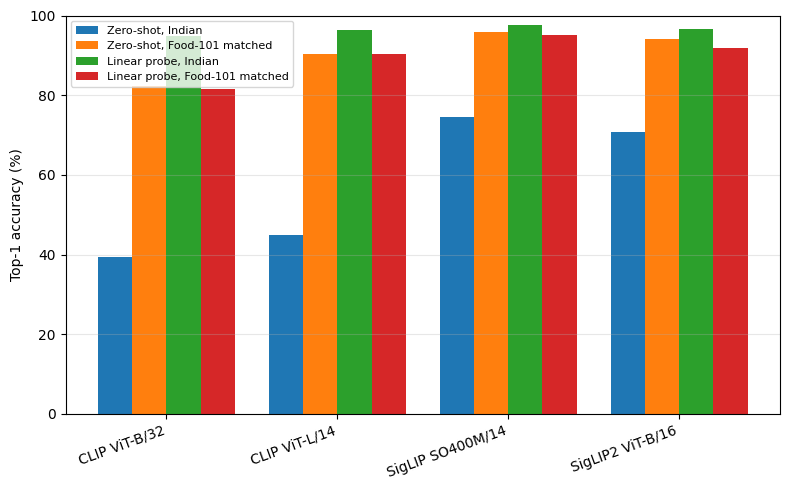


Post-split audit: test images flagged = 0 (must be 0)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import json, re, shutil
from pathlib import Path
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from scipy.stats import binomtest

P = Path('/content/drive/MyDrive/Indian_Food_Research')
assert (P / 'datasets' / 'CompressedDataset').is_dir(), 'WRONG DRIVE MOUNTED/'
OUT, FIG, PKG = P / 'results' / 'zeroshot_v2', P / 'figures', P / 'repro_package'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
def safe(s): return re.sub(r'[^A-Za-z0-9]+', '_', s).strip('_')
def l2n(X): return X / np.linalg.norm(X, axis=1, keepdims=True)

def _fit_softmax(X, y, C, n_cls=100):
    X = torch.tensor(l2n(X), device=DEVICE, dtype=torch.float32); y = torch.tensor(y, device=DEVICE, dtype=torch.long)
    W = torch.zeros(X.shape[1], n_cls, device=DEVICE, requires_grad=True); b = torch.zeros(n_cls, device=DEVICE, requires_grad=True)
    opt = torch.optim.LBFGS([W, b], lr=1, max_iter=500, history_size=20, tolerance_grad=1e-6,
                            tolerance_change=1e-9, line_search_fn='strong_wolfe')
    def closure():
        opt.zero_grad()
        loss = C * torch.nn.functional.cross_entropy(X @ W + b, y, reduction='sum') + 0.5 * (W ** 2).sum()
        loss.backward(); return loss
    opt.step(closure)
    return W.detach(), b.detach()

def fit_probe_gpu(Xtr, ytr, Xva, yva, Xte):
    best = None
    for C in [0.1, 1.0, 10.0, 100.0]:
        W, b = _fit_softmax(Xtr, ytr, C)
        with torch.no_grad():
            pred = lambda X: (torch.tensor(l2n(X), device=DEVICE, dtype=torch.float32) @ W + b).argmax(1).cpu().numpy()
            va = float((pred(Xva) == yva).mean())
            if best is None or va > best[0]:
                best = (va, C, pred(Xte))
    return best[2], best[1], best[0]

RES = OUT / 'zeroshot_probe_results.json'
results = json.loads(RES.read_text())
name = 'CLIP ViT-B/32'
z = np.load(OUT / 'features' / f'{safe(name)}.npz')
F = {k: (z[f'{k}_X'], z[f'{k}_y']) for k in ['ind_train', 'ind_val', 'ind_test', 'wes_train', 'wes_val', 'wes_test']}
r = results.get(name, {'arch': 'ViT-B-32', 'pretrained': 'laion2b_s34b_b79k', 'in_submitted_manuscript': True})
for tname in ['original', 'neutral']:
    for side in ['ind', 'wes']:
        a = np.load(OUT / f'preds_zs_{tname}_{side}_{safe(name)}.npy'); r[f'zs_{tname}_{side}'] = float((a[0] == a[1]).mean())
for side in ['ind', 'wes']:
    p, C, va = fit_probe_gpu(*F[f'{side}_train'], *F[f'{side}_val'], F[f'{side}_test'][0])
    y = F[f'{side}_test'][1]
    np.save(OUT / f'preds_lp_{side}_{safe(name)}.npy', np.vstack([y, p]))
    r.update({f'lp_{side}': float((p == y).mean()), f'lp_{side}_C': C, f'lp_{side}_val': va})
r['probe_solver'] = 'GPU L-BFGS'
results[name] = r
results = {k: results[k] for k in [name] + [k for k in results if k != name]}
RES.write_text(json.dumps(results, indent=2))
print(f"CLIP B/32 re-probed: LP Indian {100*r['lp_ind']:.2f} | Food-101 {100*r['lp_wes']:.2f}")

B = 10000; rng = np.random.default_rng(SEED)
def strat_idx(y):
    return np.concatenate([np.where(y == c)[0][rng.integers(0, (y == c).sum(), (B, (y == c).sum()))] for c in np.unique(y)], axis=1)
def corr(path):
    a = np.load(path); return a[0] == a[1]
def ci(x): return f'[{100*np.percentile(x, 2.5):.1f}, {100*np.percentile(x, 97.5):.1f}]'
def mcnemar_p(ca, cb):
    b, c = int((ca & ~cb).sum()), int((~ca & cb).sum())
    return 1.0 if b + c == 0 else binomtest(b, b + c, 0.5).pvalue

y_ind = np.load(OUT / f'preds_lp_ind_{safe(name)}.npy')[0]; y_wes = np.load(OUT / f'preds_lp_wes_{safe(name)}.npy')[0]
Bi, Bw = strat_idx(y_ind), strat_idx(y_wes)                                   # class-stratified
Ii, Iw = rng.integers(0, len(y_ind), (B, len(y_ind))), rng.integers(0, len(y_wes), (B, len(y_wes)))   # image-level

zs_rows, wm_rows = [], []
for disp, rr in results.items():
    s = safe(disp)
    li, lw = corr(OUT / f'preds_lp_ind_{s}.npy'), corr(OUT / f'preds_lp_wes_{s}.npy')
    bs_lp = lw[Bw].mean(1) - li[Bi].mean(1)
    row = {'Model': disp, 'In manuscript': rr.get('in_submitted_manuscript'), 'LP Indian': round(100*li.mean(), 2),
           'LP Food-101': round(100*lw.mean(), 2), 'LP gap (pp)': round(100*(lw.mean()-li.mean()), 2), 'LP gap CI': ci(bs_lp)}
    if 'zs_original_ind' in rr:
        for tname in ['original', 'neutral']:
            zi, zw = corr(OUT / f'preds_zs_{tname}_ind_{s}.npy'), corr(OUT / f'preds_zs_{tname}_wes_{s}.npy')
            zs_rows.append({'Model': disp, 'Templates': tname, 'Indian': round(100*zi.mean(), 2), 'Food-101 matched': round(100*zw.mean(), 2),
                            'Gap (pp)': round(100*(zw.mean()-zi.mean()), 2),
                            'Gap CI image-level': ci(zw[Iw].mean(1) - zi[Ii].mean(1)),
                            'Gap CI class-stratified': ci(zw[Bw].mean(1) - zi[Bi].mean(1))})
            if tname == 'original':
                bs_zs = zw[Bw].mean(1) - zi[Bi].mean(1); zi_o, zw_o = zi, zw
        row.update({'ZS Indian': round(100*zi_o.mean(), 2), 'ZS Food-101': round(100*zw_o.mean(), 2),
                    'ZS gap (pp)': round(100*(zw_o.mean()-zi_o.mean()), 2),
                    'Gap reduction ZS->LP (pp)': round(100*((zw_o.mean()-zi_o.mean()) - (lw.mean()-li.mean())), 2),
                    'Reduction CI': ci(bs_zs - bs_lp), 'Indian LP vs ZS McNemar p': mcnemar_p(li, zi_o)})
    wm_rows.append(row)

zs_df, wm_df = pd.DataFrame(zs_rows), pd.DataFrame(wm_rows)
zs_df.to_csv(OUT / 'table_zeroshot_original_vs_neutral_prompts.csv', index=False)
wm_df.to_csv(OUT / 'table_within_model_zeroshot_vs_linear_probe.csv', index=False)
pd.set_option('display.width', 250)
print('\nZERO-SHOT, original vs identical neutral templates (95% bootstrap CIs, B=10,000):\n', zs_df.to_string(index=False))
print('\nWITHIN-MODEL (same frozen encoder: zero-shot vs linear probe):\n', wm_df.to_string(index=False))

d = wm_df[wm_df['ZS Indian'].notna()]
x, w = np.arange(len(d)), 0.2
plt.figure(figsize=(max(8, 1.8*len(d)), 5))
for k, (col, lab) in enumerate([('ZS Indian', 'Zero-shot, Indian'), ('ZS Food-101', 'Zero-shot, Food-101 matched'),
                                ('LP Indian', 'Linear probe, Indian'), ('LP Food-101', 'Linear probe, Food-101 matched')]):
    plt.bar(x + (k - 1.5)*w, d[col], w, label=lab)
plt.xticks(x, d['Model'], rotation=20, ha='right'); plt.ylabel('Top-1 accuracy (%)'); plt.ylim(0, 100)
plt.legend(fontsize=8); plt.grid(axis='y', alpha=.3); plt.tight_layout()
plt.savefig(FIG / 'fig_within_model_zs_vs_lp.png', dpi=300); plt.savefig(FIG / 'fig_within_model_zs_vs_lp.pdf'); plt.show()

for src in [P / 'splits' / 'flagged_test_indices.json', P / 'reports' / 'duplicate_audit_summary.json', RES,
            OUT / 'table_zeroshot_original_vs_neutral_prompts.csv', OUT / 'table_within_model_zeroshot_vs_linear_probe.csv']:
    shutil.copy(src, PKG / src.name)
audit = json.loads((P / 'reports' / 'duplicate_audit_summary.json').read_text())
print('\nPost-split audit: test images flagged =', audit['test_images_flagged_any'], '(must be 0)')